# 01 - Data Generation and EDA

This notebook is the entry point for the project.

It explains the synthetic manufacturing data story, generates the public CSV files, and performs a first exploratory data analysis pass before any machine learning is introduced.

The goal is not to build a full silicon photonics simulator.

The goal is to create a controlled synthetic dataset that behaves like a simplified wafer-level manufacturing problem:

- every die has inline metrology measurements
- only some dies have downstream optical test results
- tested dies can pass or fail a downstream specification
- wafer-level and local spatial effects can create visible patterns
- resonance wavelength is generated from a simple physical sensitivity model

The main EDA question is:

> Does the generated dataset behave like a coherent wafer-level manufacturing dataset rather than arbitrary random numbers?

## Plain-language glossary

Before looking at the data, we define the main terms used throughout the project.

- **Wafer**: one circular silicon slice that contains many repeated chip locations.
- **Die**: one chip location on the wafer.
- **Inline metrology**: measurements collected during or near fabrication. In this synthetic dataset, every die has inline metrology.
- **Downstream test**: later optical test data. It is more expensive, so only some dies are tested.
- **Microring resonator**: a small ring-shaped optical device whose resonance wavelength is sensitive to geometry.
- **`lambda_res_nm`**: measured resonance wavelength in nanometers. This is the main downstream regression target.
- **`q_loaded`**: loaded quality factor. Higher usually means lower optical loss.
- **`test_pass`**: downstream pass/fail flag. `1` means pass, `0` means fail.
- **Not tested**: a die with inline metrology but no downstream row.

Let's setup the necessary libraries, custom modules and set up the project structure.

In [4]:
# Import standard libraries
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set up project structure and paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Datasets are generated and stored in the "data" directory at the project root
DATA_DIR = PROJECT_ROOT / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

# Import custom modules
from src.generator import SyntheticMRRDataGenerator
from src.physics import MRRParameters
from src.utils import (
    merge_sources,
    plot_feature_distributions,
    plot_inline_vs_resonance,
    save_sources,
    validate_schemas,
)

## How the synthetic dataset is generated

The synthetic dataset is produced by `SyntheticMRRDataGenerator` in `src/generator.py`.

For the purpose of this notebook, the generator can be treated as a black box. We do not need to inspect every implementation detail here. What matters is the data-generating story behind it.

The important idea is that the inline and downstream tables are generated from the same hidden synthetic manufacturing state. This creates a meaningful relationship between early metrology measurements and later optical test results, while keeping the hidden true values out of the public modeling dataset.

The simplified flow is:

```text
wafer layout
        ↓
hidden synthetic manufacturing state
        ↓
noisy inline metrology measurements
        ↓
partial downstream optical testing
        ↓
pass/fail downstream labels
```

### Wafer layout

The generator starts by creating a simplified wafer layout.

Each wafer contains dies placed on a regular grid. The grid is clipped by a circular wafer footprint, so the final layout resembles a simplified wafer map.

Each die receives a physical position on the wafer through `x_mm`, `y_mm`, and `r_mm`.

The radial coordinate `r_mm` measures distance from the wafer center. It is useful later when we check whether edge dies behave differently from center dies.

### Hidden synthetic manufacturing state

Behind the public CSV files, the generator creates a hidden physical state for every die.

This hidden state represents the synthetic “true” condition of the die before measurement noise is added. It includes quantities such as true waveguide width, true silicon thickness, true roughness, true defectivity, true resonance wavelength, and true Q-factor.

These hidden values are not written into the public modeling dataset. This is intentional. In a real manufacturing setting, we do not get perfect access to the true physical state of each device. We only observe measurements.

### Inline metrology measurements

The measured inline columns are noisy observations of hidden true values.

For example, the true waveguide width of die $i$ is represented as $w_i$. The inline metrology tool does not observe $w_i$ perfectly. Instead, it records a measured value:

$$
w_{i,\mathrm{meas}} = w_i + \epsilon_{i,\mathrm{width}}
$$

Similarly, the true silicon thickness of die $i$ is represented as $t_i$. The measured thickness is:

$$
t_{i,\mathrm{meas}} = t_i + \epsilon_{i,\mathrm{thickness}}
$$

Here:

- $w_i$ is the hidden true waveguide width for die $i$
- $t_i$ is the hidden true silicon thickness for die $i$
- $w_{i,\mathrm{meas}}$ is the measured inline width
- $t_{i,\mathrm{meas}}$ is the measured inline thickness
- $\epsilon_{i,\mathrm{width}}$ is measurement noise in the width measurement
- $\epsilon_{i,\mathrm{thickness}}$ is measurement noise in the thickness measurement

The noise terms are not functions of width or thickness in this simplified notation. They represent measurement uncertainty added by the metrology process.

### Downstream optical testing

The downstream table is generated later in the synthetic flow. Only some dies receive downstream optical test results.

For tested dies, the generator creates measured optical outputs such as `lambda_res_nm`, `q_loaded`, `insertion_loss_db`, and `test_pass`.

The resonance wavelength is generated from the simplified first-order physical model:

$$
\lambda_i =
\lambda_0
+
\alpha (t_i - t_0)
+
\beta (w_i - w_0)
+
\eta_i^{(\lambda)}
$$

This means that small deviations in true silicon thickness and true waveguide width shift the resonance wavelength.

The noise term $\eta_i^{(\lambda)}$ represents downstream measurement noise and residual effects not explicitly modeled.

The loaded Q-factor is generated from a simple log-linear degradation model:

$$
\log Q_i =
\log Q_0
-
k_r r_i
-
k_d d_i
+
\eta_i^{(Q)}
$$

This means that higher roughness and higher defect density reduce optical quality.

### Downstream pass/fail rule

Finally, the generator applies a downstream specification rule.

A tested die passes only if its measured resonance wavelength is inside the allowed specification window:

$$
\lambda_{\mathrm{spec,min}}
\le
\lambda_{\mathrm{res,nm}}
\le
\lambda_{\mathrm{spec,max}}
$$

and its loaded Q is above the minimum acceptable value:

$$
q_{\mathrm{loaded}} \ge q_{\mathrm{spec,min}}
$$

Otherwise, the tested die fails.

### Public output tables

The final public output is two CSV files.

`synthetic_inline_metrology.csv` has one row per die and acts as the feature-side data source.

`synthetic_downstream_wafer_test.csv` has one row per tested die and acts as the target-side data source.

If a die has no downstream row, it is treated as not tested, not as failed.

The rest of this notebook checks whether these generated tables behave like a coherent synthetic manufacturing dataset.

In [ ]:

SEED = 42

params = MRRParameters()
gen = SyntheticMRRDataGenerator(params=params, seed=SEED)

df_inline, df_downstream = gen.generate_dataset(
    n_wafers=20,
    n_dies_per_wafer=400,
    p_downstream_sample=0.50,
)

validate_schemas(df_inline, df_downstream)
save_sources(df_inline, df_downstream, output_dir=str(DATA_DIR), prefix="synthetic")

stats = gen.validate_and_summarize(df_inline, df_downstream)

summary_keys = [
    "n_dies_inline",
    "n_dies_downstream",
    "n_dies_not_tested",
    "coverage_pct",
    "not_tested_pct",
    "n_dies_downstream_pass",
    "n_dies_downstream_fail",
    "pass_rate_pct",
    "lambda_mean",
    "lambda_std",
    "q_mean",
]

Saved inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Saved downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
n_dies_inline: 8000
n_dies_downstream: 3743
n_dies_not_tested: 4257
coverage_pct: 46.788
not_tested_pct: 53.212
n_dies_downstream_pass: 2261
n_dies_downstream_fail: 1482
pass_rate_pct: 60.406
lambda_mean: 1549.166
lambda_std: 2.612
q_mean: 157488.987


## What the two tables mean

The generator writes two public CSV files.


### Inline metrology table

`synthetic_inline_metrology.csv`

This table has one row per die. It represents early measurements that are assumed to be cheaper and more available.

These measurements describe process and geometry-related quantities such as width, thickness, roughness proxy, overlay, and defect-density proxy.

### Inline metrology columns

The inline table contains one row per die. Some columns identify where the die is located, while others represent measured process or geometry quantities.

Identifier and spatial columns:

| Column | Meaning |
| --- | --- |
| `wafer_id` | Identifier of the wafer |
| `lot_id` | Identifier of the manufacturing lot |
| `die_id` | Identifier of the die on a wafer |
| `x_mm` | Die x-position on the wafer, in millimeters |
| `y_mm` | Die y-position on the wafer, in millimeters |
| `r_mm` | Distance from wafer center, in millimeters |

The spatial columns are useful because manufacturing variation is often not purely random. Dies near the wafer edge may behave differently from dies near the center.

Measured inline metrology columns:

| Column | Meaning |
| --- | --- |
| `wg_width_nm_meas` | Measured waveguide width, in nanometers |
| `soi_thickness_nm_meas` | Measured silicon layer thickness, in nanometers |
| `etch_depth_nm_meas` | Measured etch depth, in nanometers |
| `roughness_rms_nm_meas` | Measured roughness proxy, in nanometers RMS |
| `overlay_x_nm_meas` | Measured x-direction alignment error, in nanometers |
| `overlay_y_nm_meas` | Measured y-direction alignment error, in nanometers |
| `defect_density_cm2_meas` | Measured defect-density proxy, in defects per cm² (tied to silicon quality)|
| `metrology_valid` | Flag indicating whether inline metrology is usable |

In plain language, these columns describe what the fabrication process produced before optical testing happens.

For this project, the most important geometry-related inline features are `wg_width_nm_meas` and `soi_thickness_nm_meas`, because the simplified resonance model uses waveguide width and silicon thickness to generate resonance wavelength shifts.

The roughness and defect-density columns are more related to optical quality degradation, especially the loaded Q-factor. Overlay and etch-depth measurements are included as additional process-related features that make the inline table look more like a realistic metrology source.

In [16]:
display(df_inline.head(10))

,wafer_id,lot_id,die_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid
0,W001,L01,D_R001_C008,-21.304348,-63.913043,67.370263,450.746043,220.765376,78.376078,1.833024,0.582978,1.501057,3496.593408,1
1,W001,L01,D_R001_C009,-15.217391,-63.913043,65.699666,450.520529,220.106638,77.595898,2.254063,0.717936,-3.135393,2782.650722,1
2,W001,L01,D_R001_C010,-9.130435,-63.913043,64.561923,450.819875,220.039471,81.925761,2.037319,-1.049406,-0.992895,1857.644245,1
3,W001,L01,D_R001_C011,-3.043478,-63.913043,63.985466,450.597277,219.147633,86.167674,1.846491,-1.394339,-0.000943,3191.842153,1
4,W001,L01,D_R001_C012,3.043478,-63.913043,63.985466,451.583470,220.697219,82.182801,2.044996,2.122632,-1.286136,2427.490770,1
5,W001,L01,D_R001_C013,9.130435,-63.913043,64.561923,451.317631,220.962110,91.453451,1.940941,-0.117672,1.895899,2646.768093,1
6,W001,L01,D_R001_C014,15.217391,-63.913043,65.699666,450.945513,219.888457,83.711458,2.405350,-2.158408,-1.035722,3478.571069,1
7,W001,L01,D_R001_C015,21.304348,-63.913043,67.370263,452.592166,219.457249,72.792999,2.238272,-1.534218,-0.707305,2351.089300,1
8,W001,L01,D_R002_C006,-33.478261,-57.826087,66.818039,450.826661,219.811813,90.006340,2.349346,1.762772,4.954129,2195.198327,1
9,W001,L01,D_R002_C007,-27.391304,-57.826087,63.985466,451.256254,219.622184,74.024110,2.172732,0.418731,-0.081092,2373.940907,1


### Downstream optical test table

`synthetic_downstream_wafer_test.csv`

This table has one row per die that was tested downstream.

A downstream row means that the die has a usable optical test result.

A die missing from the downstream table is not automatically a failed die. It is simply not tested downstream.

The three public downstream states are:

- `Pass`: downstream row exists and `test_pass = 1`
- `Fail`: downstream row exists and `test_pass = 0`
- `Not tested`: inline row exists, but no downstream row exists

### Downstream optical test columns

The downstream table contains measured optical outcomes for the subset of dies that were tested.

Identifier and test-context columns:

| Column | Meaning |
| --- | --- |
| `wafer_id` | Identifier of the wafer |
| `die_id` | Identifier of the die on a wafer |
| `test_station_id` | Identifier of the synthetic test station used for downstream testing |

The identifiers `wafer_id` and `die_id` are used to join downstream test results back to the inline metrology table.

The `test_station_id` column represents measurement context. In real test data, different tools or stations can introduce small measurement offsets. In this synthetic dataset, it makes the downstream table look closer to a real test source, but it should not be treated as a physical device property.

Measured downstream optical columns:

| Column | Meaning |
| --- | --- |
| `lambda_res_nm` | Measured resonance wavelength, in nanometers. This is the main regression target. |
| `q_loaded` | Measured loaded quality factor. Higher values usually indicate lower optical loss and a sharper resonance. |
| `insertion_loss_db` | Measured optical insertion loss, in decibels. Higher loss means less optical power reaches the output. |
| `test_pass` | Pass/fail result for the tested die. `1` means pass, `0` means fail. |

The most important downstream quantity in this project is `lambda_res_nm`.

It represents where the microring resonance actually appears after fabrication and downstream optical testing. The baseline ML model tries to predict this value from inline metrology measurements.

The `q_loaded` column is used as a quality-related downstream metric. It is not the main regression target in the baseline notebook, but it is important for the pass/fail rule. A device can fail even if its resonance wavelength is acceptable, if its Q-factor is too low.

The `insertion_loss_db` column provides another optical performance indicator. It is included to make the downstream table more realistic, but it is not the main focus of the baseline model.

The `test_pass` column is derived from the downstream specification rule. It should not be used as an input feature when predicting `lambda_res_nm`, because it is already a downstream outcome.

In [18]:
display(df_downstream.head(10))

,wafer_id,die_id,test_station_id,lambda_res_nm,q_loaded,insertion_loss_db,test_pass
0,W011,D_R006_C003,TS3,1549.116065,150461.858416,5.025091,1
1,W017,D_R022_C014,TS2,1544.576533,172238.350848,5.021317,0
2,W005,D_R011_C017,TS2,1554.617178,171457.996705,5.018214,0
3,W007,D_R004_C006,TS1,1545.875675,133542.552263,5.034532,0
4,W001,D_R010_C009,TS3,1551.397683,193958.269519,5.038734,1
5,W004,D_R001_C015,TS1,1550.780660,145041.811901,5.031463,1
6,W013,D_R003_C004,TS2,1544.716100,169795.865053,5.024767,0
7,W009,D_R001_C010,TS2,1546.511287,175470.518339,5.021278,1
8,W010,D_R006_C017,TS3,1550.355535,171348.031328,5.018663,1
9,W004,D_R009_C010,TS1,1550.088208,156936.138803,5.019356,1


## Downstream status counts

Before looking at individual features, let's first check the basic downstream population.

This plot answers a simple question:

> Did the generator create a useful mix of pass, fail, and not-tested dies?

This matters because the project would be uninteresting if all dies passed, all dies failed, or all dies were tested.

A meaningful synthetic manufacturing dataset should contain:

- dies that pass downstream specification
- dies that fail downstream specification
- dies that were not tested downstream

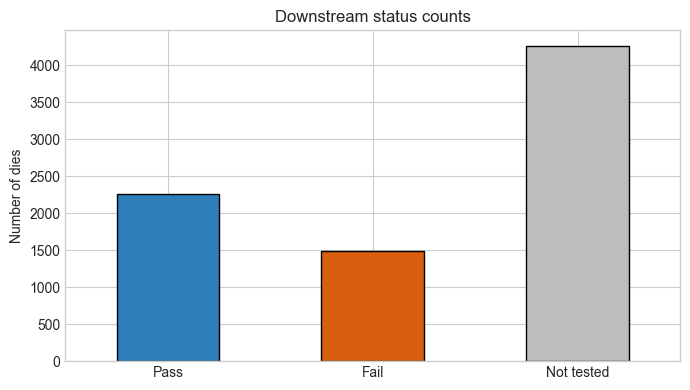

,die_count
Pass,2261
Fail,1482
Not tested,4257


In [7]:
status_counts = pd.Series({
    'Pass': int((df_downstream['test_pass'] == 1).sum()),
    'Fail': int((df_downstream['test_pass'] == 0).sum()),
    'Not tested': int(len(df_inline) - len(df_downstream)),
})

fig, ax = plt.subplots(figsize=(7, 4))
status_counts.plot(kind='bar', ax=ax, color=['#2C7FB8', '#D95F0E', '#BDBDBD'], edgecolor='black')
ax.set_title('Downstream status counts')
ax.set_ylabel('Number of dies')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

status_counts.to_frame('die_count')

The not-tested group exists because downstream optical testing is assumed to be more expensive and only partially available.

The pass/fail split exists because the generator applies a downstream specification rule based on resonance wavelength and loaded Q.

## Downstream target distributions and specification limits

The downstream table contains the measured optical quantities used by the pass/fail rule.

A tested die passes only if its resonance wavelength falls inside the allowed wavelength window:

$$
\lambda_{\mathrm{spec,min}}
\le
\lambda_{\mathrm{res,nm}}
\le
\lambda_{\mathrm{spec,max}}
$$

and its loaded Q is above the minimum Q threshold:

$$
q_{\mathrm{loaded}} \ge q_{\mathrm{spec,min}}
$$

The histograms below show how tested dies are distributed relative to these specification limits.

This plot answers:

> Is the downstream pass/fail problem meaningful?

We expect most values to be near the nominal target, but some tested dies should fall outside the allowed wavelength window or below the minimum Q threshold.

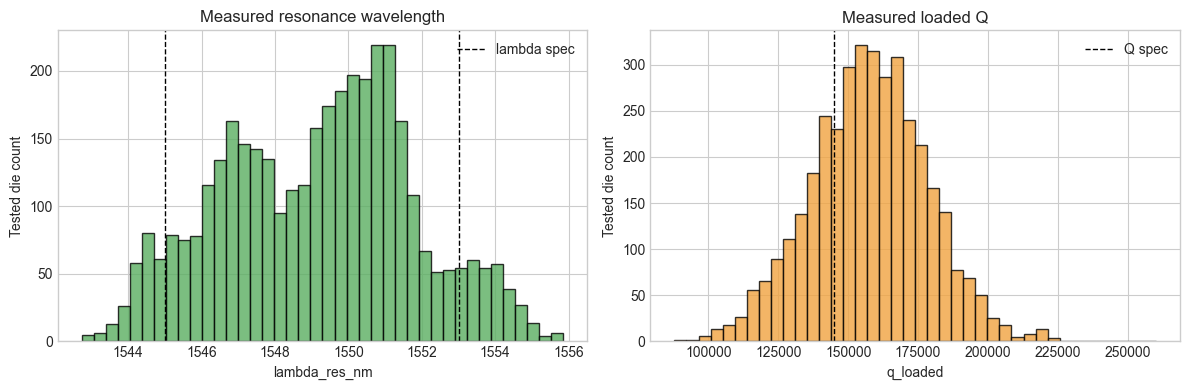

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_downstream["lambda_res_nm"],
    bins=40,
    color="#5AAE61",
    edgecolor="black",
    alpha=0.8,
)
axes[0].axvline(
    params.lambda_spec_min,
    color="black",
    linestyle="--",
    linewidth=1,
    label="lambda spec",
)
axes[0].axvline(
    params.lambda_spec_max,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set_title("Measured resonance wavelength")
axes[0].set_xlabel("lambda_res_nm")
axes[0].set_ylabel("Tested die count")
axes[0].legend()

axes[1].hist(
    df_downstream["q_loaded"],
    bins=40,
    color="#F1A340",
    edgecolor="black",
    alpha=0.8,
)
axes[1].axvline(
    params.q_spec_min,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Q spec",
)
axes[1].set_title("Measured loaded Q")
axes[1].set_xlabel("q_loaded")
axes[1].set_ylabel("Tested die count")
axes[1].legend()

plt.tight_layout()
plt.show()

The resonance wavelength histogram shows how much the optical response shifts across tested dies. The Q histogram shows whether some devices have degraded optical quality. 

## Inline feature distributions

Now we inspect the input side of the problem: the inline metrology measurements.

These histograms are a sanity check.

They do not prove that the data is real or physically complete. Instead, they check whether the generated measurements have reasonable ranges and smooth process-like variation.

For geometry-related features such as waveguide width and silicon thickness, we expect values to cluster around nominal process values.

For positive quality-related quantities such as roughness and defect-density proxy, some skew is acceptable.

This section answers:

> Do the generated inline measurements look controlled and process-like, rather than broken or arbitrary?

Things to look for:

- reasonable value ranges
- no impossible negative geometry values
- smooth variation around nominal values
- no obvious broken distributions
- different feature types having different distribution shapes

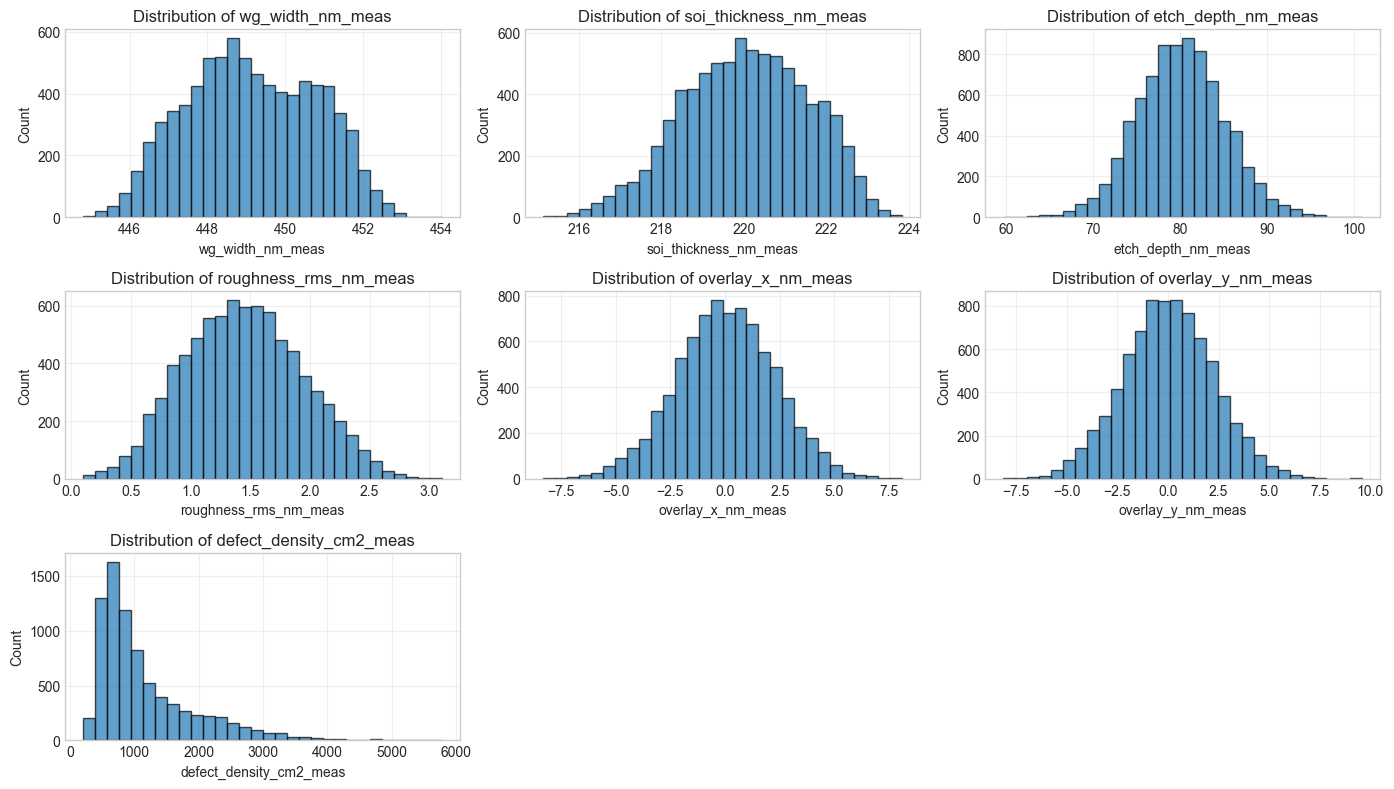

In [9]:
plot_feature_distributions(df_inline, figsize=(14, 8))

The purpose of this plot is not to claim that the synthetic data perfectly matches a real fab distribution.

The purpose is to confirm that the generator produces plausible measurement populations that can be inspected and interpreted before modeling.

## Does inline metrology explain the target?

The physical model says that resonance wavelength should mainly depend on waveguide width and silicon thickness.

This section checks whether that relationship is visible in the public observed data.

Merged tested rows: 3743


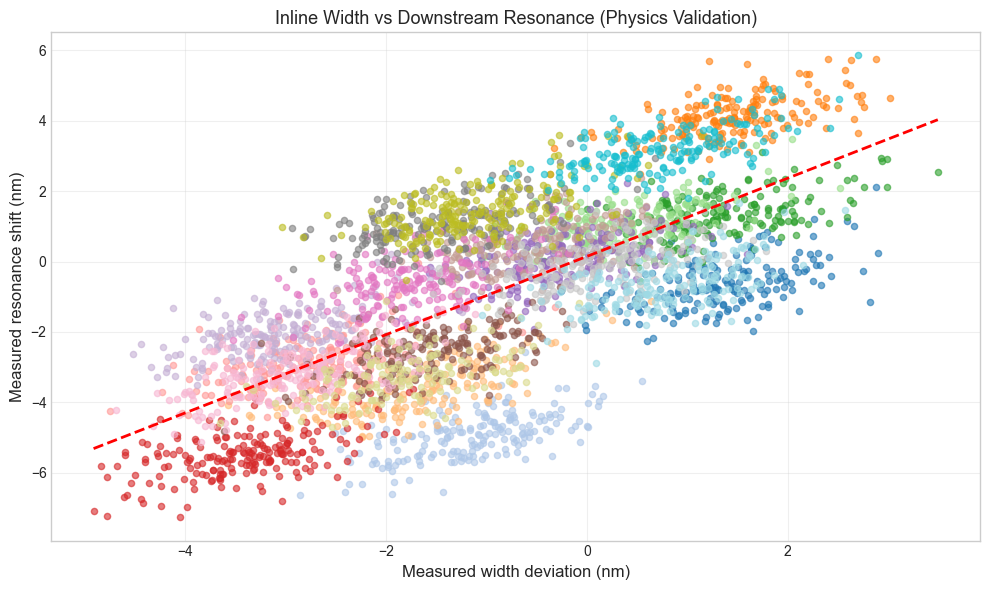

,corr_with_lambda_res_nm
soi_thickness_nm_meas,0.717886
wg_width_nm_meas,0.703811
roughness_rms_nm_meas,0.148120
defect_density_cm2_meas,-0.037318
etch_depth_nm_meas,0.030932
overlay_y_nm_meas,-0.016461
overlay_x_nm_meas,0.002450


In [10]:
df_tested = merge_sources(df_inline, df_downstream, how="inner")
print(f"Merged tested rows: {len(df_tested)}")

plot_inline_vs_resonance(df_tested)

feature_cols = [
    "wg_width_nm_meas",
    "soi_thickness_nm_meas",
    "etch_depth_nm_meas",
    "roughness_rms_nm_meas",
    "overlay_x_nm_meas",
    "overlay_y_nm_meas",
    "defect_density_cm2_meas",
]

corr = (
    df_tested[feature_cols + ["lambda_res_nm"]]
    .corr(numeric_only=True)["lambda_res_nm"]
    .drop("lambda_res_nm")
)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

display(corr.to_frame("corr_with_lambda_res_nm"))

The correlation table is important because it checks whether the strongest features are the physically expected ones.

For this project, the most important inline features should be:

- `wg_width_nm_meas`
- `soi_thickness_nm_meas`

These are the measured versions of the width and thickness terms used by the first-order resonance model.

If these features are most correlated with `lambda_res_nm`, the observed public data is consistent with the physical story used by the generator.

### Combined physical signal proxy

Width and thickness both contribute to resonance shift.

Instead of looking at one feature at a time, we can build a simple physical signal proxy using the same sensitivity structure as the generator:

$$
\alpha(t_{\mathrm{meas}} - t_0) + \beta(w_{\mathrm{meas}} - w_0)
$$

This is not used as a hidden truth variable. It is computed only from public measured inline columns.

If the observed data follows the intended physical story, this proxy should have a clear relationship with the measured resonance shift.

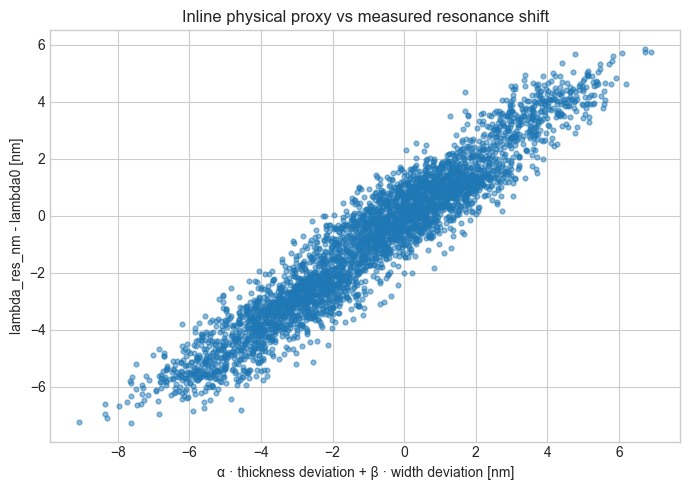

Correlation between inline physical proxy and resonance shift: 0.954


In [12]:
df_tested = df_tested.copy()

df_tested["lambda_shift_nm"] = (
    df_tested["lambda_res_nm"] - params.lambda0
)

df_tested["inline_physics_proxy_nm"] = (
    params.alpha
    * (df_tested["soi_thickness_nm_meas"] - params.t0)
    +
    params.beta
    * (df_tested["wg_width_nm_meas"] - params.w0)
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df_tested["inline_physics_proxy_nm"],
    df_tested["lambda_shift_nm"],
    s=12,
    alpha=0.5,
)

ax.set_title("Inline physical proxy vs measured resonance shift")
ax.set_xlabel("α · thickness deviation + β · width deviation [nm]")
ax.set_ylabel("lambda_res_nm - lambda0 [nm]")

plt.tight_layout()
plt.show()

proxy_corr = (
    df_tested[["inline_physics_proxy_nm", "lambda_shift_nm"]]
    .corr()
    .iloc[0, 1]
)

print(f"Correlation between inline physical proxy and resonance shift: {proxy_corr:.3f}")

This plot is useful because it connects the physical model directly to the observed public data.

The relationship does not need to be perfect. Measurement noise, spatial effects, and downstream noise should create scatter.

However, a clear positive trend means that the inline metrology measurements contain the expected physical signal.

## Coverage and failure by wafer radius

Each die has a position on the wafer.

The column `r_mm` measures how far a die is from the wafer center.

A radial summary groups dies by distance from the wafer center:

- center
- mid-inner
- mid-outer
- edge

For each radial group, we calculate:

- how many dies exist
- how many were tested downstream
- how many failed
- downstream coverage rate
- fail rate among tested dies

This is a compact numerical check before drawing full wafer maps.

The generator intentionally includes spatial effects, including edge-related degradation. Therefore, we expect edge dies to behave differently from center dies.

This section answers:

> Do downstream coverage and failure behavior change from wafer center to wafer edge?

In [ ]:
df_status = df_inline.merge(
    df_downstream[["wafer_id", "die_id", "test_pass"]],
    on=["wafer_id", "die_id"],
    how="left",
)

df_status["tested_downstream"] = df_status["test_pass"].notna()
df_status["failed_downstream"] = df_status["test_pass"].eq(0)

df_status["radius_bin"] = pd.qcut(
    df_status["r_mm"],
    q=4,
    labels=["center", "mid-inner", "mid-outer", "edge"],
)

radius_summary = (
    df_status.groupby("radius_bin", observed=True)
    .agg(
        die_count=("die_id", "size"),
        tested_count=("tested_downstream", "sum"),
        fail_count=("failed_downstream", "sum"),
    )
)

radius_summary["coverage_rate"] = (
    radius_summary["tested_count"] / radius_summary["die_count"]
)

radius_summary["fail_rate_among_tested"] = (
    radius_summary["fail_count"] / radius_summary["tested_count"]
)

display(radius_summary)

fig, ax = plt.subplots(figsize=(7, 4))

radius_summary[
    ["coverage_rate", "fail_rate_among_tested"]
].plot(kind="bar", ax=ax)

ax.set_title("Downstream coverage and fail rate by radius")
ax.set_ylabel("Rate")
ax.set_xlabel("Radius bin")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

If the synthetic spatial story is visible, the edge region should show worse downstream behavior than the center region.

For example, edge dies may have:

- lower downstream coverage
- higher fail rate among tested dies

This prepares the reader for the next notebook, where the same spatial behavior is shown directly as wafer maps.